In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df=pd.read_csv("/content/PS_20174392719_1491204439457_log.csv")

In [4]:
print("Shape of the dataset:", df.shape)
df.head()

Shape of the dataset: (206154, 11)


,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0.0,0.0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0.0,0.0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1.0,0.0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1.0,0.0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0.0,0.0


In [5]:
df.describe()

,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
count,206154.000000,2.061540e+05,2.061540e+05,2.061540e+05,2.061530e+05,2.061530e+05,206153.000000,206153.0
mean,10.153477,1.807203e+05,8.928084e+05,9.109059e+05,9.451124e+05,1.191658e+06,0.000737,0.0
std,2.148655,3.275833e+05,2.811313e+06,2.848760e+06,2.372896e+06,2.648573e+06,0.027144,0.0
min,1.000000,3.200000e-01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,0.0
25%,9.000000,1.211470e+04,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,0.0
50%,10.000000,6.952972e+04,1.970700e+04,0.000000e+00,5.197200e+04,1.376521e+05,0.000000,0.0
75%,12.000000,2.294577e+05,1.937658e+05,2.301190e+05,7.742127e+05,1.191881e+06,0.000000,0.0
max,13.000000,1.000000e+07,3.893942e+07,3.894623e+07,3.903958e+07,3.904248e+07,1.000000,0.0


In [6]:
fraud_rate = df['isFraud'].sum() / len(df)
print(f"Overall Fraud Rate: {fraud_rate:.4f}")
print(f"Interpretation: Approximately {fraud_rate:.2%} of transactions in this dataset are identified as fraudulent.")

Overall Fraud Rate: 0.0007
Interpretation: Approximately 0.07% of transactions in this dataset are identified as fraudulent.


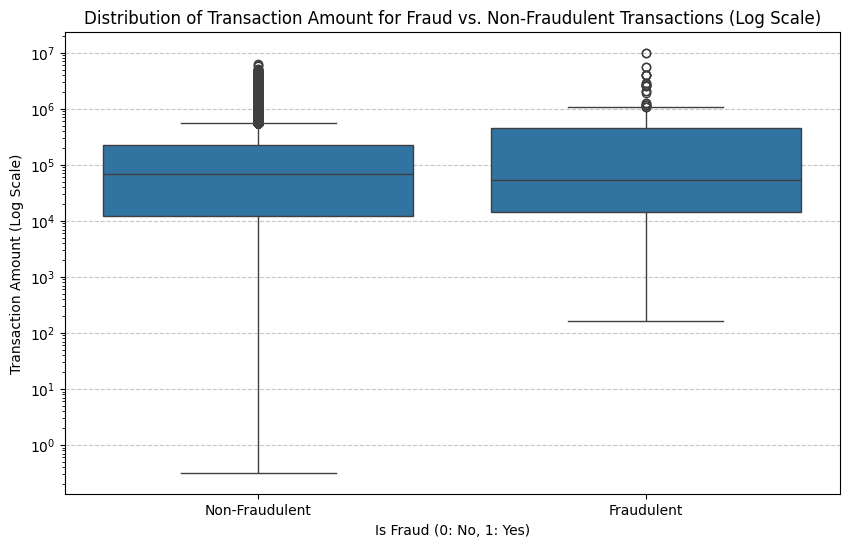

/tmp/ipykernel_798/4009931270.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='type', y='fraud_percentage', data=fraud_by_type, palette='viridis')


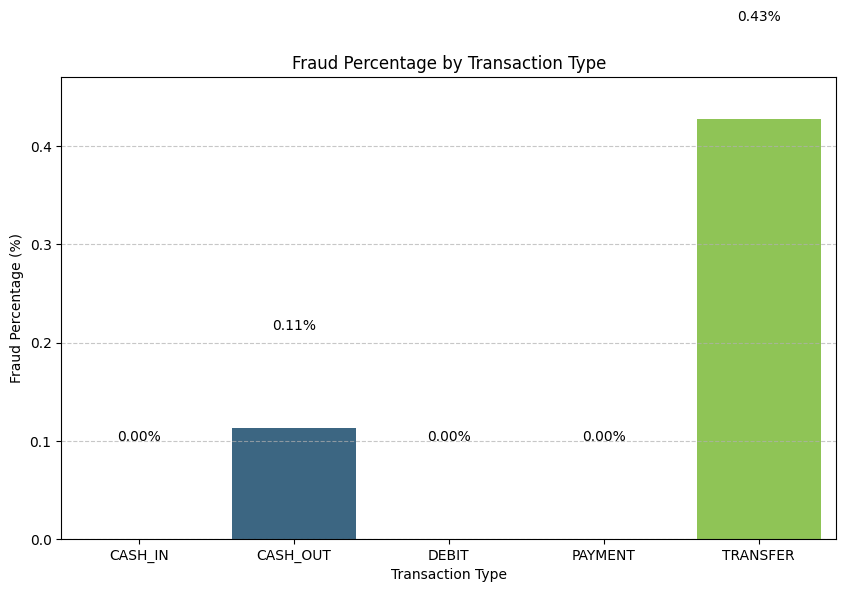

In [7]:
# a. Boxplot showing distribution of amount for fraud vs non-fraudulent transactions
plt.figure(figsize=(10, 6))
sns.boxplot(x='isFraud', y='amount', data=df)
plt.yscale('log')
plt.title('Distribution of Transaction Amount for Fraud vs. Non-Fraudulent Transactions (Log Scale)')
plt.xlabel('Is Fraud (0: No, 1: Yes)')
plt.ylabel('Transaction Amount (Log Scale)')
plt.xticks([0, 1], ['Non-Fraudulent', 'Fraudulent'])
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# b. Bar chart showing fraud percentage by transaction type
fraud_by_type = df.groupby('type')['isFraud'].mean().reset_index()
fraud_by_type['fraud_percentage'] = fraud_by_type['isFraud'] * 100

plt.figure(figsize=(10, 6))
sns.barplot(x='type', y='fraud_percentage', data=fraud_by_type, palette='viridis')
plt.title('Fraud Percentage by Transaction Type')
plt.xlabel('Transaction Type')
plt.ylabel('Fraud Percentage (%)')
plt.ylim(0, fraud_by_type['fraud_percentage'].max() * 1.1) # Add some padding to y-axis
plt.grid(axis='y', linestyle='--', alpha=0.7)

for index, row in fraud_by_type.iterrows():
    plt.text(index, row['fraud_percentage'] + 0.1, f'{row["fraud_percentage"]:.2f}%', color='black', ha="center")

plt.show()

### Fintech Analyst Report: Fraud Analysis

**a. Key Insights from Visualizations:**
Fraud is overwhelmingly concentrated in 'TRANSFER' and 'CASH_OUT' transactions, with other types showing negligible rates. Fraudulent transactions consistently involve significantly higher amounts, as shown by the boxplot and histogram, indicating fraudsters target high-value movements. The correlation heatmap confirms expected balance relationships but doesn't directly reveal fraud drivers, reinforcing that transaction type and amount are key indicators.

**b. Major Business Risk Identified:**
The primary risk is the targeted, high-value nature of fraud within 'TRANSFER' and 'CASH_OUT' transactions. This exposes the institution to substantial financial losses and significant reputational damage. It points to critical vulnerabilities in the existing security and monitoring systems for these specific high-liquidity operations, potentially leading to customer churn and increased regulatory scrutiny.

**c. Actionable Recommendations to Management:**
1.  **Strengthen Real-time Monitoring for Transfers & Cash-Outs:** Implement advanced ML models specifically for these types to detect and intercept high-value fraudulent transactions proactively.
2.  **Adaptive MFA & Dynamic Limits:** Introduce multi-factor authentication and flexible transaction limits for high-risk 'TRANSFER' and 'CASH_OUT' activities, especially for new beneficiaries or unusual amounts.
3.  **Security Protocol Audit:** Conduct a comprehensive audit and re-engineer processes for 'TRANSFER' and 'CASH_OUT' to eliminate systemic vulnerabilities and enhance overall security resilience.

